In [ ]:
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Cargar dataset desde Kaggle
file_path = "CarPrice_Assignment.csv"
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "hellbuoy/car-price-prediction",
    file_path,
)

# Ver primeras filas
print("Primeras 5 filas del dataset:")
print(df.head())

# Tamaño del dataset
print(f"\nCantidad de filas y columnas: {df.shape}")

# Revisar columnas disponibles
print("\nColumnas del dataset:")
print(df.columns.tolist())

# Verificar datos nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())

<ipython-input-1-877e56b6c957>:7: DeprecationWarning: load_dataset is deprecated and will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 26.1k/26.1k [00:00<00:00, 5.31MB/s]

Primeras 5 filas del dataset:
   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressionratio 

In [ ]:
# Revisar tipo de datos de cada columna
print("\nTipos de datos:")
print(df.dtypes)

# Convertir columnas necesarias a numéricas (por si acaso)
# No deberían necesitar conversión, pero aseguramos que lo estén
df['engine-size'] = pd.to_numeric(df['enginesize'], errors='coerce')
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df['curb-weight'] = pd.to_numeric(df['curbweight'], errors='coerce')
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Filtramos el DataFrame con solo las columnas que vamos a usar
df_model = df[['engine-size', 'horsepower', 'curb-weight', 'price']]

# Verificar valores nulos nuevamente
print("\nValores nulos después de la conversión:")
print(df_model.isnull().sum())

# Eliminar filas con valores nulos
df_model.dropna(inplace=True)

# Confirmar datos finales
print(f"\nTamaño final del dataset para modelado: {df_model.shape}")
print(df_model.head())



Tipos de datos:
car_ID                int64
symboling             int64
CarName              object
fueltype             object
aspiration           object
doornumber           object
carbody              object
drivewheel           object
enginelocation       object
wheelbase           float64
carlength           float64
carwidth            float64
carheight           float64
curbweight            int64
enginetype           object
cylindernumber       object
enginesize            int64
fuelsystem           object
boreratio           float64
stroke              float64
compressionratio    float64
horsepower            int64
peakrpm               int64
citympg               int64
highwaympg            int64
price               float64
dtype: object

Valores nulos después de la conversión:
engine-size    0
horsepower     0
curb-weight    0
price          0
dtype: int64

Tamaño final del dataset para modelado: (205, 4)
   engine-size  horsepower  curb-weight    price
0          130      

<ipython-input-2-ab0c07a4a53b>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model.dropna(inplace=True)


1.
*   Muestras: 205 registros
*   Variable dependiente: price
*   Variables predictoras seleccionadas: engine-size, horsepower y curb-weight.



2. Relación entre variables predictoras y la variable de salida.

<Figure size 1000x800 with 0 Axes>

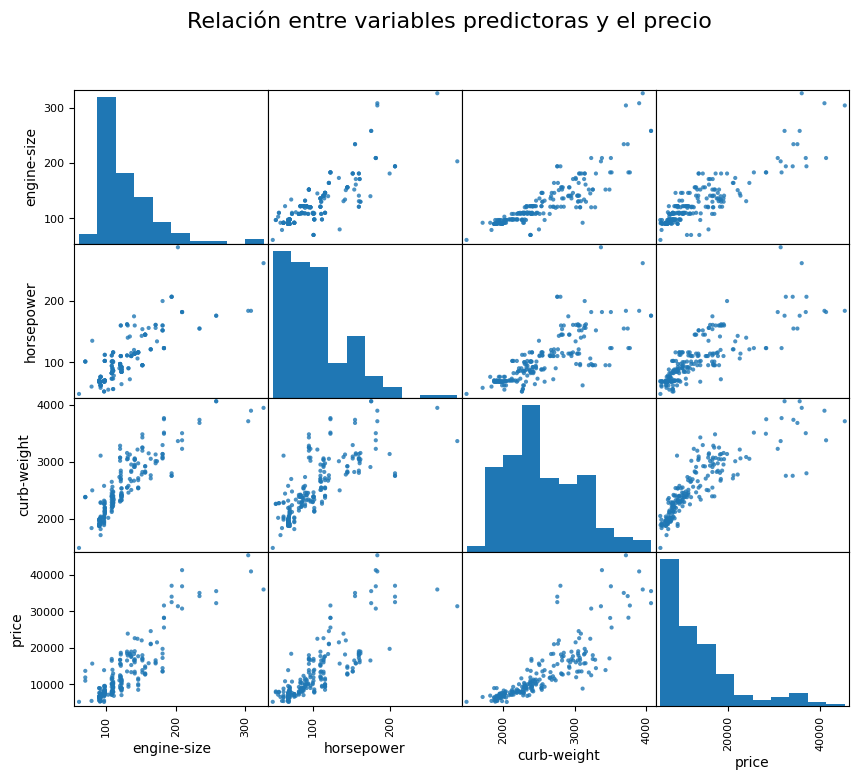

In [ ]:
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

# Visualización de relaciones
plt.figure(figsize=(10, 8))
scatter_matrix(df_model, alpha=0.8, figsize=(10, 8), diagonal='hist')
plt.suptitle('Relación entre variables predictoras y el precio', fontsize=16)
plt.show()


3.1 Cambio en las proporciones de train/test set.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Variables independientes y dependiente
X = df_model[['engine-size', 'horsepower', 'curb-weight']]
y = df_model['price']

# Proporciones a probar
splits = [(0.3, "70/30"), (0.5, "50/50"), (0.6, "40/60")]

# Evaluar el modelo en cada proporción
for test_size, label in splits:
    print(f"Proporción {label} (test size = {test_size}):")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"MSE: {mse:.2f}")
    print(f"R² Score: {r2:.4f}")


Proporción 70/30 (test size = 0.3):
MSE: 14790927.38
R² Score: 0.7865
Proporción 50/50 (test size = 0.5):
MSE: 11894814.11
R² Score: 0.7873
Proporción 40/60 (test size = 0.6):
MSE: 12395386.79
R² Score: 0.7804


3.2 Cambio del método de optimización del modelo.

In [ ]:
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

# Separar nuevamente variables
X = df_model[['engine-size', 'horsepower', 'curb-weight']]
y = df_model['price']

# División 70/30 como ejemplo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Escalar características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Crear y entrenar modelo con SGD
sgd_model = SGDRegressor(max_iter=1000, tol=1e-3, penalty=None, eta0=0.01, random_state=42)
sgd_model.fit(X_train_scaled, y_train)

# Predicciones
y_pred_sgd = sgd_model.predict(X_test_scaled)

# Evaluación
mse_sgd = mean_squared_error(y_test, y_pred_sgd)
r2_sgd = r2_score(y_test, y_pred_sgd)

print("Resultado con SGDRegressor:")
print(f"MSE: {mse_sgd:.2f}")
print(f"R² Score: {r2_sgd:.4f}")


Resultado con SGDRegressor:
MSE: 14883073.58
R² Score: 0.7852


3.3 Métodos de regularización.


In [ ]:
from sklearn.linear_model import Lasso, Ridge, ElasticNet

# Escalar nuevamente si es necesario
X_scaled = scaler.fit_transform(X)
y = df_model['price']

# División fija para comparación (70/30)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Lasso (L1)
lasso = Lasso(alpha=0.5)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
print("\nLasso (L1):")
print("Coeficientes:", lasso.coef_)
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("R²:", r2_score(y_test, y_pred_lasso))

# Ridge (L2)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
print("\nRidge (L2):")
print("Coeficientes:", ridge.coef_)
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("R²:", r2_score(y_test, y_pred_ridge))

# ElasticNet (L1 + L2)
elastic = ElasticNet(alpha=1.0, l1_ratio=0.5)
elastic.fit(X_train, y_train)
y_pred_elastic = elastic.predict(X_test)
print("\nElasticNet (L1 + L2):")
print("Coeficientes:", elastic.coef_)
print("MSE:", mean_squared_error(y_test, y_pred_elastic))
print("R²:", r2_score(y_test, y_pred_elastic))



Lasso (L1):
Coeficientes: [3333.46830847 1965.04702224 2289.24976407]
MSE: 14791193.764284212
R²: 0.78651473736568

Ridge (L2):
Coeficientes: [3292.72696614 1977.19440849 2298.68526257]
MSE: 14809215.552176999
R²: 0.7862546240724094

ElasticNet (L1 + L2):
Coeficientes: [2332.25472816 1948.07515306 2094.5827908 ]
MSE: 16934679.14065353
R²: 0.7555772386201776


3.4 y 3.5 Pesos, intercepto, MSE y R²



In [ ]:
# Reentrenar modelo Lasso (ya lo habíamos hecho, pero lo repetimos por claridad)
final_model = Lasso(alpha=0.5)
final_model.fit(X_train, y_train)

# Predicciones
final_pred = final_model.predict(X_test)

# Coeficientes y métricas
print("Coeficientes del modelo final (Lasso):")
for feature, coef in zip(['engine-size', 'horsepower', 'curb-weight'], final_model.coef_):
    print(f"{feature}: {coef:.2f}")

print(f"\nIntercepto (b0): {final_model.intercept_:.2f}")

# Evaluación
final_mse = mean_squared_error(y_test, final_pred)
final_r2 = r2_score(y_test, final_pred)

print(f"\nMSE del modelo final: {final_mse:.2f}")
print(f"R² del modelo final: {final_r2:.4f}")


Coeficientes del modelo final (Lasso):
engine-size: 3333.47
horsepower: 1965.05
curb-weight: 2289.25

Intercepto (b0): 13243.24

MSE del modelo final: 14791193.76
R² del modelo final: 0.7865


4. Conclusiones en el Readme